### News

Train MoEs - DeepSeek, GLM, Qwen and gpt-oss 12x faster with 35% less VRAM. [Blog](https://unsloth.ai/docs/new/faster-moe)

You can now train embedding models 1.8-3.3x faster with 20% less VRAM. [Blog](https://unsloth.ai/docs/new/embedding-finetuning)

Ultra Long-Context Reinforcement Learning is here with 7x more context windows! [Blog](https://unsloth.ai/docs/new/grpo-long-context)

3x faster LLM training with 30% less VRAM and 500K context. [3x faster](https://unsloth.ai/docs/new/3x-faster-training-packing) • [500K Context](https://unsloth.ai/docs/new/500k-context-length-fine-tuning)

New in Reinforcement Learning: [FP8 RL](https://unsloth.ai/docs/new/fp8-reinforcement-learning) • [Vision RL](https://unsloth.ai/docs/new/vision-reinforcement-learning-vlm-rl) • [Standby](https://unsloth.ai/docs/basics/memory-efficient-rl) • [gpt-oss RL](https://unsloth.ai/docs/new/gpt-oss-reinforcement-learning)

Visit our docs for all our [model uploads](https://unsloth.ai/docs/get-started/unsloth-model-catalog) and [notebooks](https://unsloth.ai/docs/get-started/unsloth-notebooks).

### Installation

In [ ]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth  # Do this in local & cloud setups
else:
    import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
    xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2
!pip install jiwer
!pip install einops addict easydict

### Unsloth

Let's prepare the OCR model to our local first

In [ ]:
from huggingface_hub import snapshot_download
snapshot_download("unsloth/DeepSeek-OCR-2", local_dir = "deepseek_ocr2")

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

LICENSE.txt: 0.00B [00:00, ?B/s]

.gitattributes: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

configuration_deepseek_v2.py: 0.00B [00:00, ?B/s]

...

modeling_deepseekv2.py: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/801 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

'/content/deepseek_ocr2'

In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"  # Reduce fragmentación VRAM en T4

from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch
from transformers import AutoModel
os.environ["UNSLOTH_WARN_UNINITIALIZED"] = '0'
# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
fourbit_models = [
    "unsloth/Qwen3-VL-8B-Instruct-bnb-4bit", # Qwen 3 vision support
    "unsloth/Qwen3-VL-8B-Thinking-bnb-4bit",
    "unsloth/Qwen3-VL-32B-Instruct-bnb-4bit",
    "unsloth/Qwen3-VL-32B-Thinking-bnb-4bit",
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastVisionModel.from_pretrained(
    "./deepseek_ocr2",
    load_in_4bit = False, # Use 4bit to reduce memory use. False for 16bit LoRA.
    auto_model = AutoModel,
    trust_remote_code = True,
    unsloth_force_compile = True,
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

### Let's Evaluate Deepseek-OCR Baseline Performance on Persian Transcription

In [ ]:
import json
from pathlib import Path
from PIL import Image
from google.colab import files, userdata
from huggingface_hub import snapshot_download, login

HF_TOKEN = userdata.get('HF_TOKEN')
login(token=HF_TOKEN)

# 1) Sube tu dataset_golden.jsonl local (133 líneas) desde tu PC
print("👉 Sube dataset_golden.jsonl (133 líneas):")
uploaded = files.upload()
jsonl_name = next(iter(uploaded))

# 2) Descarga SOLO la carpeta original/ desde el repo Lacax/Tickets en HF
print("\n📥 Descargando original/ de Lacax/Tickets...")
repo_local = snapshot_download(
    repo_id="Lacax/Tickets",
    repo_type="dataset",
    token=HF_TOKEN,
    allow_patterns=["original/*"],
)
originals_dir = Path(repo_local) / "original"
print(f"   Imágenes en: {originals_dir}")

# 3) Construir dataset en memoria: lista de dicts con misma forma que cord-v2
#    (image: PIL.Image, ground_truth: string JSON)
dataset = []
missing = []
with open(jsonl_name, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        row = json.loads(line)
        img_path = originals_dir / row["image_path"]
        if not img_path.exists():
            missing.append(row["image_path"])
            continue
        gt = row["ground_truth"]
        gt_str = json.dumps(gt, ensure_ascii=False) if isinstance(gt, (dict, list)) else str(gt)
        dataset.append({
            "image": Image.open(img_path).convert("RGB"),
            "ground_truth": gt_str,
        })

print(f"\n✅ Muestras cargadas: {len(dataset)}")
if missing:
    print(f"⚠ {len(missing)} imágenes no encontradas en original/: {missing[:5]}")
print(f"\nEjemplo ground_truth (200 chars):\n{dataset[0]['ground_truth'][:200]}")

In [ ]:
# Save an image that will not be used during training for evaluation purposes
dataset[23]['image'].save("your_image.jpg")

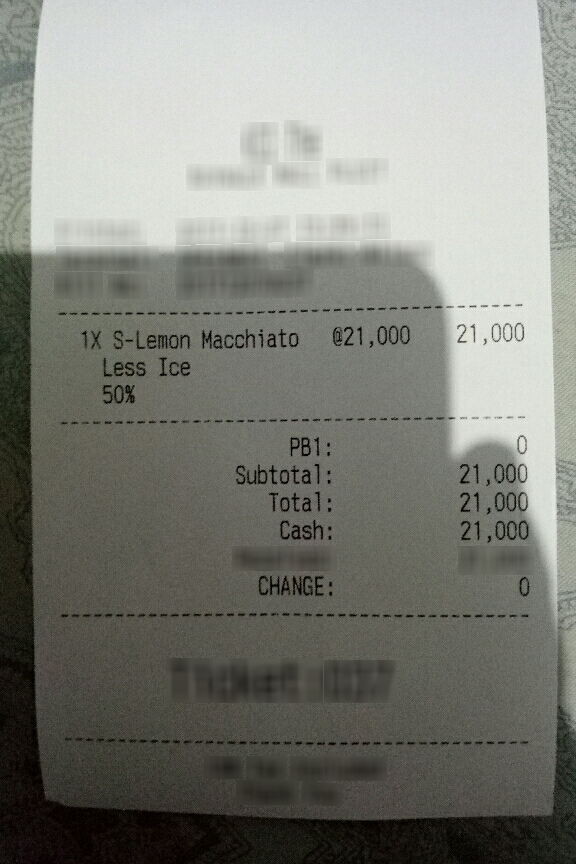

In [ ]:
dataset[23]['image']

In [ ]:
dataset[23]["ground_truth"]

<h3>Baseline Model Performance: 23% Character Error Rate (CER) for this sample !</h3>

# Let's finetune Deepseek-OCR !

We now add LoRA adapters for parameter efficient finetuning - this allows us to only efficiently train 1% of all parameters.

**[NEW]** We also support finetuning ONLY the vision part of the model, or ONLY the language part. Or you can select both! You can also select to finetune the attention or the MLP layers!

In [ ]:
model = FastVisionModel.get_peft_model(
    model,
    target_modules = [
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
        "gate_proj",
        "up_proj",
        "down_proj",
    ],

    r = 16,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

Unsloth: Detected MoE model with num_experts = 64 and target_modules = ['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj']. Enabling LoRA on MoE parameters: ['mlp.experts.gate_up_proj', 'mlp.experts.down_proj']
Unsloth: PEFT set target_parameters but found no matching parameters.
This is expected for MoE models - Unsloth handles MoE expert LoRA targeting separately.
Unsloth: Making `model.base_model.model.model` require gradients


<a name="Data"></a>
### Data Prep
We'll be using a dataset for Persian OCR. The goal is to convert these images into a computer readable form - ie text. This can be very useful for digitizing Persian text.

You can access the dataset [here](https://huggingface.co/datasets/hezarai/parsynth-ocr-200k).

To format the dataset, all vision finetuning tasks should be formatted as follows:

```python
[
{ "role": "<|User|>",
  "content": "",
  "images": []
},
{ "role": "<|Assistant|>",
  "content": ""
},
]
```

In [ ]:
import json
import re

instruction = """<image>

Extract the following information from the receipt and return it STRICTLY as a valid JSON object matching this structure:

{

  "comercio": "string",

  "cif": "string",

  "fecha": "string (YYYY-MM-DD)",

  "total": "number",

  "items": [{"cantidad": "number", "descripcion": "string", "precio": "number"}]

}

NO other text. ONLY valid JSON.

"""

def parse_lacax_ground_truth(gt_str):
    """Parse el campo ground_truth de Lacax/Tickets.
    Intenta json.loads directo; usa regex como fallback.
    """
    try:
        return json.loads(gt_str)
    except (json.JSONDecodeError, TypeError):
        match = re.search(r'\{.*\}', str(gt_str), re.DOTALL)
        if match:
            return json.loads(match.group(0))
        raise ValueError(f"No se pudo parsear ground_truth: {str(gt_str)[:120]}")


def convert_to_conversation(sample):
    """Convierte una muestra de dataset_golden al formato de conversación de DeepSeek-OCR-2."""
    gt = parse_lacax_ground_truth(sample["ground_truth"])

    # Schema completo: comercio, cif, fecha (ISO), total, items[cantidad, descripcion, precio]
    # Se omite fecha_original (redundante con fecha)
    output = {
        "comercio": gt.get("comercio", ""),
        "cif": gt.get("cif", ""),
        "fecha": gt.get("fecha", ""),
        "total": gt.get("total", 0),
        "items": [
            {
                "cantidad": item.get("cantidad"),
                "descripcion": item.get("descripcion", ""),
                "precio": item.get("precio", 0),
            }
            for item in gt.get("items", [])
        ],
    }

    conversation = [
        {
            "role": "<|User|>",
            "content": instruction,
            "images": [sample["image"]],
        },
        {
            "role": "<|Assistant|>",
            "content": json.dumps(output, ensure_ascii=False),
        },
    ]
    return {"messages": conversation}

# dataset ya está cargado en cell-9 (lista en memoria con image PIL + ground_truth str)

In [ ]:
converted_dataset = [convert_to_conversation(sample) for sample in dataset]

We look at how the conversations are structured for the first example:

In [ ]:
converted_dataset[0]

{'messages': [{'role': '<|User|>',
   'content': '<image>\n\nExtract the following information from the receipt and return it STRICTLY as a valid JSON object matching this structure:\n\n{\n\n\xa0 "comercio": "string",\n\n\xa0 "cif": "string",\n\n\xa0 "total": "number",\n\n\xa0 "items": [{"descripcion": "string", "precio": "number"}]\n\n}\n\nNO other text. ONLY valid JSON.\n\n',
   'images': [<PIL.PngImagePlugin.PngImageFile image mode=RGB size=864x1296>]},
  {'role': '<|Assistant|>',
   'content': '{"menu": [{"nm": "Nasi Campur Bali", "cnt": "1 x", "price": "75,000"}, {"nm": "Bbk Bengil Nasi", "cnt": "1 x", "price": "125,000"}, {"nm": "MilkShake Starwb", "cnt": "1 x", "price": "37,000"}, {"nm": "Ice Lemon Tea", "cnt": "1 x", "price": "24,000"}, {"nm": "Nasi Ayam Dewata", "cnt": "1 x", "price": "70,000"}, {"nm": "Free Ice Tea", "cnt": "3 x", "price": "0"}, {"nm": "Organic Green Sa", "cnt": "1 x", "price": "65,000"}, {"nm": "Ice Tea", "cnt": "1 x", "price": "18,000"}, {"nm": "Ice Orange"

In [ ]:
import torch
import math
from dataclasses import dataclass
from typing import Dict, List, Any, Tuple
from PIL import Image, ImageOps
from torch.nn.utils.rnn import pad_sequence
import io

from deepseek_ocr2.modeling_deepseekocr2 import (
    format_messages,
    text_encode,
    BasicImageTransform,
    dynamic_preprocess,
)

@dataclass
class DeepSeekOCR2DataCollator:
    """
    Args:
        tokenizer: Tokenizer
        model: Model
        image_size: Size for image patches (default: 768)
        base_size: Size for global view (default: 1024)
        crop_mode: Whether to use dynamic cropping for large images
        train_on_responses_only: If True, only train on assistant responses (mask user prompts)
    """
    tokenizer: Any
    model: Any
    image_size: int = 768
    base_size: int = 1024
    crop_mode: bool = True
    image_token_id: int = 128815
    train_on_responses_only: bool = True

    def __init__(
        self,
        tokenizer,
        model,
        image_size: int = 768,
        base_size: int = 1024,
        crop_mode: bool = True,
        train_on_responses_only: bool = True,
    ):
        self.tokenizer = tokenizer
        self.model = model
        self.image_size = image_size
        self.base_size = base_size
        self.crop_mode = crop_mode
        self.image_token_id = 128815
        self.dtype = model.dtype  # Get dtype from model
        self.train_on_responses_only = train_on_responses_only

        self.image_transform = BasicImageTransform(
            mean = (0.5, 0.5, 0.5),
            std = (0.5, 0.5, 0.5),
            normalize = True
        )
        self.patch_size = 16
        self.downsample_ratio = 4

        # Get BOS token ID from tokenizer
        if hasattr(tokenizer, 'bos_token_id') and tokenizer.bos_token_id is not None:
            self.bos_id = tokenizer.bos_token_id
        else:
            self.bos_id = 0
            print(f"Warning: tokenizer has no bos_token_id, using default: {self.bos_id}")

    def deserialize_image(self, image_data) -> Image.Image:
        """Convert image data (bytes dict or PIL Image) to PIL Image in RGB mode"""
        if isinstance(image_data, Image.Image):
            img = image_data.convert("RGB")
        elif isinstance(image_data, dict) and 'bytes' in image_data:
            image_bytes = image_data['bytes']
            img = Image.open(io.BytesIO(image_bytes))
            img = img.convert("RGB")
        else:
            raise ValueError(f"Unsupported image format: {type(image_data)}")
        return ImageOps.exif_transpose(img) # Apply EXIF rotation

    def visualize_image(self, image: Image.Image, title: str = ""):
        """Displays the image for visualization purposes."""
        # You can add more sophisticated visualization logic here (e.g., using matplotlib)
        print(f"Displaying image: {title}")
        image.show() # This will attempt to open the image in a viewer

    def calculate_image_token_count(self, image: Image.Image, crop_ratio: Tuple[int, int]) -> int:
        """Calculate the number of tokens this image will generate"""
        num_queries = math.ceil((self.image_size // self.patch_size) / self.downsample_ratio)
        num_queries_base = math.ceil((self.base_size // self.patch_size) / self.downsample_ratio)

        width_crop_num, height_crop_num = crop_ratio

        if self.crop_mode:
            img_tokens = num_queries_base * num_queries_base + 1
            if width_crop_num > 1 or height_crop_num > 1:
                img_tokens += (num_queries * width_crop_num) * (num_queries * height_crop_num)
        else:
            img_tokens = num_queries * num_queries + 1

        return img_tokens

    def process_image(self, image: Image.Image) -> Tuple[List, List, List, List, Tuple[int, int]]:
        """
        Process a single image based on crop_mode and size thresholds

        Returns:
            Tuple of (images_list, images_crop_list, images_spatial_crop, tokenized_image, crop_ratio)
        """
        images_list = []
        images_crop_list = []
        images_spatial_crop = []

        if self.crop_mode:
            # Determine crop ratio based on image size
            if image.size[0] <= 768 and image.size[1] <= 768:
                crop_ratio = (1, 1)
                images_crop_raw = []
            else:
                images_crop_raw, crop_ratio = dynamic_preprocess(
                    image, min_num = 2, max_num = 6,
                    image_size = self.image_size, use_thumbnail = False
                )

            # Process global view with padding
            global_view = ImageOps.pad(
                image, (self.base_size, self.base_size),
                color = tuple(int(x * 255) for x in self.image_transform.mean)
            )
            images_list.append(self.image_transform(global_view).to(self.dtype))

            width_crop_num, height_crop_num = crop_ratio
            images_spatial_crop.append([width_crop_num, height_crop_num])

            # Process local views (crops) if applicable
            if width_crop_num > 1 or height_crop_num > 1:
                for crop_img in images_crop_raw:
                    images_crop_list.append(
                        self.image_transform(crop_img).to(self.dtype)
                    )

            # Calculate image tokens
            num_queries = math.ceil((self.image_size // self.patch_size) / self.downsample_ratio)
            num_queries_base = math.ceil((self.base_size // self.patch_size) / self.downsample_ratio)

            tokenized_image = ([self.image_token_id] * num_queries_base) * num_queries_base
            tokenized_image += [self.image_token_id]

            if width_crop_num > 1 or height_crop_num > 1:
                tokenized_image += ([self.image_token_id] * (num_queries * width_crop_num)) * (
                    num_queries * height_crop_num)

        else:  # crop_mode = False
            crop_ratio = (1, 1)
            images_spatial_crop.append([1, 1])

            # For smaller base sizes, resize; for larger, pad
            if self.base_size <= 768:
                resized_image = image.resize((self.base_size, self.base_size), Image.LANCZOS)
                images_list.append(self.image_transform(resized_image).to(self.dtype))
            else:
                global_view = ImageOps.pad(
                    image, (self.base_size, self.base_size),
                    color = tuple(int(x * 255) for x in self.image_transform.mean)
                )
                images_list.append(self.image_transform(global_view).to(self.dtype))

            num_queries = math.ceil((self.base_size // self.patch_size) / self.downsample_ratio)
            tokenized_image = ([self.image_token_id] * num_queries) * num_queries
            tokenized_image += [self.image_token_id]

        return images_list, images_crop_list, images_spatial_crop, tokenized_image, crop_ratio

    def process_single_sample(self, messages: List[Dict]) -> Dict[str, Any]:
        """
        Process a single conversation into model inputs.
        """

        # --- 1. Setup ---
        images = []
        for message in messages:
            if "images" in message and message["images"]:
                for img_data in message["images"]:
                    if img_data is not None:
                        pil_image = self.deserialize_image(img_data)
                        # Optionally visualize the image after rotation
                        # self.visualize_image(pil_image, title="Processed Image")
                        images.append(pil_image)

        if not images:
            raise ValueError("No images found in sample. Please ensure all samples contain images.")

        tokenized_str = []
        images_seq_mask = []
        images_list, images_crop_list, images_spatial_crop = [], [], []

        prompt_token_count = -1 # Index to start training
        assistant_started = False
        image_idx = 0

        # Add BOS token at the very beginning
        tokenized_str.append(self.bos_id)
        images_seq_mask.append(False)

        for message in messages:
            role = message["role"]
            content = message["content"]

            # Check if this is the assistant's turn
            if role == "<|Assistant|>" :
                if not assistant_started:
                    # This is the split point. All tokens added *so far*
                    # are part of the prompt.
                    prompt_token_count = len(tokenized_str)
                    assistant_started = True

                # Append the EOS token string to the *end* of assistant content
                content = f"{content.strip()} {self.tokenizer.eos_token}"

            # Split this message's content by the image token
            text_splits = content.split('<image>')

            for i, text_sep in enumerate(text_splits):
                # Tokenize the text part
                tokenized_sep = text_encode(self.tokenizer, text_sep, bos = False, eos = False)
                tokenized_str.extend(tokenized_sep)
                images_seq_mask.extend([False] * len(tokenized_sep))

                # If this text is followed by an <image> tag
                if i < len(text_splits) - 1:
                    if image_idx >= len(images):
                        raise ValueError(
                            f"Data mismatch: Found '<image>' token but no corresponding image."
                        )

                    # Process the image
                    image = images[image_idx]
                    img_list, crop_list, spatial_crop, tok_img, _ = self.process_image(image)

                    images_list.extend(img_list)
                    images_crop_list.extend(crop_list)
                    images_spatial_crop.extend(spatial_crop)

                    # Add image placeholder tokens
                    tokenized_str.extend(tok_img)
                    images_seq_mask.extend([True] * len(tok_img))

                    image_idx += 1 # Move to the next image

        # --- 3. Validation and Final Prep ---
        if image_idx != len(images):
            raise ValueError(
                f"Data mismatch: Found {len(images)} images but only {image_idx} '<image>' tokens were used."
            )

        # If we never found an assistant message, we're in a weird state
        # (e.g., user-only prompt). We mask everything.
        if not assistant_started:
            print("Warning: No assistant message found in sample. Masking all tokens.")
            prompt_token_count = len(tokenized_str)

        # Prepare image tensors
        images_ori = torch.stack(images_list, dim = 0)
        images_spatial_crop_tensor = torch.tensor(images_spatial_crop, dtype = torch.long)

        if images_crop_list:
            images_crop = torch.stack(images_crop_list, dim = 0)
        else:
            images_crop = torch.zeros((1, 3, self.base_size, self.base_size), dtype = self.dtype)

        return {
            "input_ids": torch.tensor(tokenized_str, dtype = torch.long),
            "images_seq_mask": torch.tensor(images_seq_mask, dtype = torch.bool),
            "images_ori": images_ori,
            "images_crop": images_crop,
            "images_spatial_crop": images_spatial_crop_tensor,
            "prompt_token_count": prompt_token_count, # This is now accurate
        }

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        """Collate batch of samples"""
        batch_data = []

        # Process each sample
        for feature in features:
            try:
                processed = self.process_single_sample(feature['messages'])
                batch_data.append(processed)
            except Exception as e:
                print(f"Error processing sample: {e}")
                continue

        if not batch_data:
            raise ValueError("No valid samples in batch")

        # Extract lists
        input_ids_list = [item['input_ids'] for item in batch_data]
        images_seq_mask_list = [item['images_seq_mask'] for item in batch_data]
        prompt_token_counts = [item['prompt_token_count'] for item in batch_data]

        # Pad sequences
        input_ids = pad_sequence(input_ids_list, batch_first = True, padding_value = self.tokenizer.pad_token_id)
        images_seq_mask = pad_sequence(images_seq_mask_list, batch_first = True, padding_value = False)

        # Create labels
        labels = input_ids.clone()

        # Mask padding tokens
        labels[labels == self.tokenizer.pad_token_id] = -100

        # Mask image tokens (model shouldn't predict these)
        labels[images_seq_mask] = -100

        # Mask user prompt tokens when train_on_responses_only = True (only train on assistant responses)
        if self.train_on_responses_only:
            for idx, prompt_count in enumerate(prompt_token_counts):
                if prompt_count > 0:
                    labels[idx, :prompt_count] = -100

        # Create attention mask
        attention_mask = (input_ids != self.tokenizer.pad_token_id).long()

        # Prepare images batch (list of tuples)
        images_batch = []
        for item in batch_data:
            images_batch.append((item['images_crop'], item['images_ori']))

        # Stack spatial crop info
        images_spatial_crop = torch.cat([item['images_spatial_crop'] for item in batch_data], dim = 0)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
            "images": images_batch,
            "images_seq_mask": images_seq_mask,
            "images_spatial_crop": images_spatial_crop,
        }

<a name="Train"></a>
### Train the model
Now let's train our model. We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`. We also support `DPOTrainer` and `GRPOTrainer` for reinforcement learning!!

We use our new `DeepSeekOCR2DataCollator` which will help in our vision finetuning setup.

In [ ]:
import torch
import math
from dataclasses import dataclass
from typing import Dict, List, Any, Tuple
from PIL import Image, ImageOps
from torch.nn.utils.rnn import pad_sequence
import io

from deepseek_ocr2.modeling_deepseekocr2 import (
    format_messages,
    text_encode,
    BasicImageTransform,
    dynamic_preprocess,
)

@dataclass
class DeepSeekOCR2DataCollator:
    """
    Args:
        tokenizer: Tokenizer
        model: Model
        image_size: Size for image patches (default: 768)
        base_size: Size for global view (default: 1024)
        crop_mode: Whether to use dynamic cropping for large images
        train_on_responses_only: If True, only train on assistant responses (mask user prompts)
        max_length: Truncate sequences longer than this (default: None = no truncation)
    """
    tokenizer: Any
    model: Any
    image_size: int = 768
    base_size: int = 1024
    crop_mode: bool = True
    image_token_id: int = 128815
    train_on_responses_only: bool = True
    max_length: int = None

    def __init__(
        self,
        tokenizer,
        model,
        image_size: int = 768,
        base_size: int = 1024,
        crop_mode: bool = True,
        train_on_responses_only: bool = True,
        max_length: int = None,
    ):
        self.tokenizer = tokenizer
        self.model = model
        self.image_size = image_size
        self.base_size = base_size
        self.crop_mode = crop_mode
        self.image_token_id = 128815
        self.dtype = model.dtype  # Get dtype from model
        self.train_on_responses_only = train_on_responses_only
        self.max_length = max_length

        self.image_transform = BasicImageTransform(
            mean = (0.5, 0.5, 0.5),
            std = (0.5, 0.5, 0.5),
            normalize = True
        )
        self.patch_size = 16
        self.downsample_ratio = 4

        # Get BOS token ID from tokenizer
        if hasattr(tokenizer, 'bos_token_id') and tokenizer.bos_token_id is not None:
            self.bos_id = tokenizer.bos_token_id
        else:
            self.bos_id = 0
            print(f"Warning: tokenizer has no bos_token_id, using default: {self.bos_id}")

    def deserialize_image(self, image_data) -> Image.Image:
        """Convert image data (bytes dict or PIL Image) to PIL Image in RGB mode"""
        if isinstance(image_data, Image.Image):
            img = image_data.convert("RGB")
        elif isinstance(image_data, dict) and 'bytes' in image_data:
            image_bytes = image_data['bytes']
            img = Image.open(io.BytesIO(image_bytes))
            img = img.convert("RGB")
        else:
            raise ValueError(f"Unsupported image format: {type(image_data)}")
        return ImageOps.exif_transpose(img) # Apply EXIF rotation

    def visualize_image(self, image: Image.Image, title: str = ""):
        """Displays the image for visualization purposes."""
        print(f"Displaying image: {title}")
        image.show()

    def calculate_image_token_count(self, image: Image.Image, crop_ratio: Tuple[int, int]) -> int:
        """Calculate the number of tokens this image will generate"""
        num_queries = math.ceil((self.image_size // self.patch_size) / self.downsample_ratio)
        num_queries_base = math.ceil((self.base_size // self.patch_size) / self.downsample_ratio)

        width_crop_num, height_crop_num = crop_ratio

        if self.crop_mode:
            img_tokens = num_queries_base * num_queries_base + 1
            if width_crop_num > 1 or height_crop_num > 1:
                img_tokens += (num_queries * width_crop_num) * (num_queries * height_crop_num)
        else:
            img_tokens = num_queries * num_queries + 1

        return img_tokens

    def process_image(self, image: Image.Image) -> Tuple[List, List, List, List, Tuple[int, int]]:
        images_list = []
        images_crop_list = []
        images_spatial_crop = []

        if self.crop_mode:
            if image.size[0] <= 768 and image.size[1] <= 768:
                crop_ratio = (1, 1)
                images_crop_raw = []
            else:
                images_crop_raw, crop_ratio = dynamic_preprocess(
                    image, min_num = 2, max_num = 6,
                    image_size = self.image_size, use_thumbnail = False
                )

            global_view = ImageOps.pad(
                image, (self.base_size, self.base_size),
                color = tuple(int(x * 255) for x in self.image_transform.mean)
            )
            images_list.append(self.image_transform(global_view).to(self.dtype))

            width_crop_num, height_crop_num = crop_ratio
            images_spatial_crop.append([width_crop_num, height_crop_num])

            if width_crop_num > 1 or height_crop_num > 1:
                for crop_img in images_crop_raw:
                    images_crop_list.append(
                        self.image_transform(crop_img).to(self.dtype)
                    )

            num_queries = math.ceil((self.image_size // self.patch_size) / self.downsample_ratio)
            num_queries_base = math.ceil((self.base_size // self.patch_size) / self.downsample_ratio)

            tokenized_image = ([self.image_token_id] * num_queries_base) * num_queries_base
            tokenized_image += [self.image_token_id]

            if width_crop_num > 1 or height_crop_num > 1:
                tokenized_image += ([self.image_token_id] * (num_queries * width_crop_num)) * (
                    num_queries * height_crop_num)

        else:
            crop_ratio = (1, 1)
            images_spatial_crop.append([1, 1])

            if self.base_size <= 768:
                resized_image = image.resize((self.base_size, self.base_size), Image.LANCZOS)
                images_list.append(self.image_transform(resized_image).to(self.dtype))
            else:
                global_view = ImageOps.pad(
                    image, (self.base_size, self.base_size),
                    color = tuple(int(x * 255) for x in self.image_transform.mean)
                )
                images_list.append(self.image_transform(global_view).to(self.dtype))

            num_queries = math.ceil((self.base_size // self.patch_size) / self.downsample_ratio)
            tokenized_image = ([self.image_token_id] * num_queries) * num_queries
            tokenized_image += [self.image_token_id]

        return images_list, images_crop_list, images_spatial_crop, tokenized_image, crop_ratio

    def process_single_sample(self, messages: List[Dict]) -> Dict[str, Any]:
        images = []
        for message in messages:
            if "images" in message and message["images"]:
                for img_data in message["images"]:
                    if img_data is not None:
                        pil_image = self.deserialize_image(img_data)
                        images.append(pil_image)

        if not images:
            raise ValueError("No images found in sample.")

        tokenized_str = []
        images_seq_mask = []
        images_list, images_crop_list, images_spatial_crop = [], [], []

        prompt_token_count = -1
        assistant_started = False
        image_idx = 0

        tokenized_str.append(self.bos_id)
        images_seq_mask.append(False)

        for message in messages:
            role = message["role"]
            content = message["content"]

            if role == "<|Assistant|>":
                if not assistant_started:
                    prompt_token_count = len(tokenized_str)
                    assistant_started = True
                content = f"{content.strip()} {self.tokenizer.eos_token}"

            text_splits = content.split('<image>')

            for i, text_sep in enumerate(text_splits):
                tokenized_sep = text_encode(self.tokenizer, text_sep, bos = False, eos = False)
                tokenized_str.extend(tokenized_sep)
                images_seq_mask.extend([False] * len(tokenized_sep))

                if i < len(text_splits) - 1:
                    if image_idx >= len(images):
                        raise ValueError("Data mismatch: <image> sin imagen.")
                    image = images[image_idx]
                    img_list, crop_list, spatial_crop, tok_img, _ = self.process_image(image)

                    images_list.extend(img_list)
                    images_crop_list.extend(crop_list)
                    images_spatial_crop.extend(spatial_crop)

                    tokenized_str.extend(tok_img)
                    images_seq_mask.extend([True] * len(tok_img))

                    image_idx += 1

        if image_idx != len(images):
            raise ValueError(f"Data mismatch: {len(images)} imágenes, {image_idx} tokens <image>.")

        if not assistant_started:
            print("Warning: No assistant message in sample.")
            prompt_token_count = len(tokenized_str)

        # === Truncado defensivo: corta secuencias muy largas para evitar OOM ===
        # Solo trunca al final (parte del assistant response). Nunca corta image tokens
        # mientras max_length sea >= prompt_token_count + un margen razonable.
        if self.max_length is not None and len(tokenized_str) > self.max_length:
            tokenized_str = tokenized_str[: self.max_length]
            images_seq_mask = images_seq_mask[: self.max_length]

        images_ori = torch.stack(images_list, dim = 0)
        images_spatial_crop_tensor = torch.tensor(images_spatial_crop, dtype = torch.long)

        if images_crop_list:
            images_crop = torch.stack(images_crop_list, dim = 0)
        else:
            images_crop = torch.zeros((1, 3, self.base_size, self.base_size), dtype = self.dtype)

        return {
            "input_ids": torch.tensor(tokenized_str, dtype = torch.long),
            "images_seq_mask": torch.tensor(images_seq_mask, dtype = torch.bool),
            "images_ori": images_ori,
            "images_crop": images_crop,
            "images_spatial_crop": images_spatial_crop_tensor,
            "prompt_token_count": prompt_token_count,
        }

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        batch_data = []

        for feature in features:
            try:
                processed = self.process_single_sample(feature['messages'])
                batch_data.append(processed)
            except Exception as e:
                print(f"Error processing sample: {e}")
                continue

        if not batch_data:
            raise ValueError("No valid samples in batch")

        input_ids_list = [item['input_ids'] for item in batch_data]
        images_seq_mask_list = [item['images_seq_mask'] for item in batch_data]
        prompt_token_counts = [item['prompt_token_count'] for item in batch_data]

        input_ids = pad_sequence(input_ids_list, batch_first = True, padding_value = self.tokenizer.pad_token_id)
        images_seq_mask = pad_sequence(images_seq_mask_list, batch_first = True, padding_value = False)

        labels = input_ids.clone()
        labels[labels == self.tokenizer.pad_token_id] = -100
        labels[images_seq_mask] = -100

        if self.train_on_responses_only:
            for idx, prompt_count in enumerate(prompt_token_counts):
                if prompt_count > 0:
                    labels[idx, :prompt_count] = -100

        attention_mask = (input_ids != self.tokenizer.pad_token_id).long()

        images_batch = []
        for item in batch_data:
            images_batch.append((item['images_crop'], item['images_ori']))

        images_spatial_crop = torch.cat([item['images_spatial_crop'] for item in batch_data], dim = 0)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
            "images": images_batch,
            "images_seq_mask": images_seq_mask,
            "images_spatial_crop": images_spatial_crop,
        }

In [ ]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = Tesla T4. Max memory = 14.563 GB.
6.684 GB of memory reserved.


In [ ]:
from transformers import Trainer, TrainingArguments
from unsloth import is_bf16_supported
FastVisionModel.for_training(model) # Enable for training!

# Tamaños válidos del modelo: 512, 768, 1024, 1280
# Gundam (1024 base + 768 crops): mejor para tickets, +tokens
# Small (768/768, crop_mode=False): más ligero, ~145 image tokens vs ~833 de Gundam
data_collator = DeepSeekOCR2DataCollator(
    tokenizer = tokenizer,
    model = model,
    image_size = 768,
    base_size = 768,
    crop_mode = False,    # Modo "Small": sin crops dinámicos → mucho menos VRAM
    train_on_responses_only = True,
    max_length = 3000,
)
trainer = Trainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = data_collator,
    train_dataset = converted_dataset,
    args = TrainingArguments(
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 8,
        warmup_steps = 5,
        #max_steps = 60,
        num_train_epochs = 3,
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        fp16 = not is_bf16_supported(),
        bf16 = is_bf16_supported(),
        output_dir = "outputs",
        report_to = "none",
        dataloader_num_workers = 2,
        remove_unused_columns = False,
    ),
)

In [ ]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

3497.5813 seconds used for training.
58.29 minutes used for training.
Peak reserved memory = 13.877 GB.
Peak reserved memory for training = 7.193 GB.
Peak reserved memory % of max memory = 95.289 %.
Peak reserved memory for training % of max memory = 49.392 %.


<a name="Inference"></a>
### Inference
Let's run the model!

In [ ]:
# prompt = "<image>\nFree OCR. "
prompt = """<image>

Extract the following information from the receipt and return it STRICTLY as a valid JSON object matching this structure:

{

  "comercio": "string",

  "cif": "string",

  "total": "number",

  "items": [{"descripcion": "string", "precio": "number"}]

}

NO other text. ONLY valid JSON.

"""
image_file = 'IMG_4350.jpg'
output_path = 'your/output/dir'
# infer(self, tokenizer, prompt = '', image_file = '', output_path = ' ', base_size = 1024, image_size = 768, crop_mode = True, test_compress = False, save_results = False):

# Tiny: base_size = 512, image_size = 512, crop_mode = False
# Small: base_size = 768, image_size = 768, crop_mode = False
# Base: base_size = 1024, image_size = 1024, crop_mode = False
# Large: base_size = 1280, image_size = 1280, crop_mode = False

# Gundam: base_size = 1024, image_size = 768, crop_mode = True

res = model.infer(tokenizer, prompt = prompt, image_file = image_file, output_path = output_path, base_size = 1024, image_size = 768, crop_mode = True, save_results = True, test_compress = False)

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


1X S-Lemon Macchiato @21,000 21,000  
Less Ice 50% 0  

PB1: 0  
Subtotal: 21,000  
Total: 21,000 21,000  

Cash: 21,000  

CHANGE: 0
===============save results:===============


image: 0it [00:00, ?it/s]
other: 0it [00:00, ?it/s]


With only 60 steps, we dramatically improved the transcription quality. The Character Error Rate (CER) on this single sample dropped from 23% to 6%, a 74% relative reduction!

| Type | OCR |
| :--- | :--- |
| **Baseline (Pre-Finetune)** | `انضباطم نندم حقيقتن باورم نميتند` |
| **Finetuned (60 steps)** | `انضباطم نشدم حقیقتن باورم نمیشد` |
| **Ground Truth** | `انضباطمم شدم حقیقتن باورم نمیشد` |

In [ ]:
import json
import re
import io
import contextlib
from google.colab import files
from unsloth import FastVisionModel

FastVisionModel.for_inference(model)  # Modo inferencia

prompt = """<image>

Extract the following information from the receipt and return it STRICTLY as a valid JSON object matching this structure:

{

  "comercio": "string",

  "cif": "string",

  "fecha": "string (YYYY-MM-DD)",

  "total": "number",

  "items": [{"cantidad": "number", "descripcion": "string", "precio": "number"}]

}

NO other text. ONLY valid JSON.

"""

# 1) Sube una imagen
print("👉 Sube una imagen de ticket (.jpg/.png):")
uploaded = files.upload()
image_file = next(iter(uploaded))

# 2) Inferencia capturando stdout (model.infer imprime el resultado y devuelve None)
buf = io.StringIO()
with contextlib.redirect_stdout(buf):
    _ = model.infer(
        tokenizer,
        prompt = prompt,
        image_file = image_file,
        output_path = "/content/inference_out",
        base_size = 768,
        image_size = 768,
        crop_mode = False,
        save_results = False,
        test_compress = False,
    )
res = buf.getvalue()

# 3) Mostrar respuesta cruda capturada
print("="*60)
print("RESPUESTA RAW:")
print("="*60)
print(res)

# 4) Extraer y parsear JSON
print("\n" + "="*60)
print("JSON PARSEADO:")
print("="*60)
match = re.search(r'\{.*\}', res, re.DOTALL)
if match:
    try:
        parsed = json.loads(match.group(0))
        print(json.dumps(parsed, indent=2, ensure_ascii=False))
    except json.JSONDecodeError as e:
        print(f"⚠ Error parseando JSON: {e}")
        print(f"\nFragmento extraído:\n{match.group(0)[:500]}")
else:
    print("⚠ No se encontró ningún bloque JSON en la respuesta")

In [ ]:
from google.colab import userdata

HF_TOKEN = userdata.get('HF_TOKEN') # Make sure you've stored your Hugging Face token under the name 'HF_TOKEN' in Colab's secrets manager.

In [ ]:
model.save_pretrained("deepseek_ocr_lora_lacax")  # Local saving
tokenizer.save_pretrained("deepseek_ocr_lora_lacax")
model.push_to_hub("Lacax/deepseek_ocr_lora_lacax", token=HF_TOKEN)  # Online saving
tokenizer.push_to_hub("Lacax/deepseek_ocr_lora_lacax", token=HF_TOKEN)  # Online saving

Now if you want to load the LoRA adapters we just saved for inference, set `False` to `True`:

In [ ]:
if False:
    from unsloth import FastVisionModel
    model, tokenizer = FastVisionModel.from_pretrained(
        model_name = "deepseek_ocr_lora", # YOUR MODEL YOU USED FOR TRAINING
        load_in_4bit = False, # Use 4bit to reduce memory use. False for 16bit LoRA.
        auto_model = AutoModel,
        trust_remote_code = True,
        unsloth_force_compile = True,
        use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
    )
    FastVisionModel.for_inference(model) # Enable for inference!

prompt = "<image>\nFree OCR. "
image_file = 'IMG_4348.jpg'
output_path = 'your/output/dir'

# Tiny: base_size = 512, image_size = 512, crop_mode = False
# Small: base_size = 768, image_size = 768, crop_mode = False
# Base: base_size = 1024, image_size = 1024, crop_mode = False
# Large: base_size = 1280, image_size = 1280, crop_mode = False

# Gundam: base_size = 1024, image_size = 768, crop_mode = True

res = model.infer(tokenizer, prompt = prompt, image_file = image_file,
    output_path = output_path,
    image_size = 768,
    base_size = 1024,
    crop_mode = True,
    save_results = True,
    test_compress = False)

error: [Errno 2] No such file or directory: 'IMG_4348.jpg'


AttributeError: 'NoneType' object has no attribute 'convert'

### Saving to float16 for VLLM

We also support saving to `float16` directly. Select `merged_16bit` for float16. Use `push_to_hub_merged` to upload to your Hugging Face account! You can go to https://huggingface.co/settings/tokens for your personal tokens. See [our docs](https://unsloth.ai/docs/basics/inference-and-deployment) for more deployment options.

In [ ]:
# Select ONLY 1 to save! (Both not needed!)

# Save locally to 16bit
if False: model.save_pretrained_merged("unsloth_finetune", tokenizer,)

# To export and save to your Hugging Face account
if False: model.push_to_hub_merged("YOUR_USERNAME/unsloth_finetune", tokenizer, token = "YOUR_HF_TOKEN")

And we're done! If you have any questions on Unsloth, we have a [Discord](https://discord.gg/unsloth) channel! If you find any bugs or want to keep updated with the latest LLM stuff, or need help, join projects etc, feel free to join our Discord!

Some other resources:
1. Train your own reasoning model - Llama GRPO notebook [Free Colab](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3.1_(8B)-GRPO.ipynb)
2. Saving finetunes to Ollama. [Free notebook](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3_(8B)-Ollama.ipynb)
3. Llama 3.2 Vision finetuning - Radiography use case. [Free Colab](https://colab.research.google.com/github/unslothai/notebooks/blob/main/nb/Llama3.2_(11B)-Vision.ipynb)
4. See notebooks for DPO, ORPO, Continued pretraining, conversational finetuning and more on our [documentation](https://unsloth.ai/docs/get-started/unsloth-notebooks)!

<div class="align-center">
  <a href="https://unsloth.ai"><img src="https://github.com/unslothai/unsloth/raw/main/images/unsloth%20new%20logo.png" width="115"></a>
  <a href="https://discord.gg/unsloth"><img src="https://github.com/unslothai/unsloth/raw/main/images/Discord.png" width="145"></a>
  <a href="https://unsloth.ai/docs/"><img src="https://github.com/unslothai/unsloth/blob/main/images/documentation%20green%20button.png?raw=true" width="125"></a>

  Join Discord if you need help + ⭐️ <i>Star us on <a href="https://github.com/unslothai/unsloth">Github</a> </i> ⭐️

  This notebook and all Unsloth notebooks are licensed [LGPL-3.0](https://github.com/unslothai/notebooks?tab=LGPL-3.0-1-ov-file#readme)
</div>